In [1]:
# @title Importing

from __future__ import annotations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.profiler import schedule
import torchmetrics
from ignite.engine import Events
from ignite.metrics import Metric, Loss
from ignite.handlers import global_step_from_engine, EarlyStopping
from torch.optim.lr_scheduler import _LRScheduler, ReduceLROnPlateau, CosineAnnealingWarmRestarts, ChainedScheduler
from ignite.contrib.handlers import TensorboardLogger
from ignite.contrib.handlers.tensorboard_logger import *
from ignite.exceptions import NotComputableError

import lightning as L
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, ModelSummary
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.profilers import SimpleProfiler, PyTorchProfiler
from lightning.pytorch.utilities.warnings import PossibleUserWarning

from torch.optim.lr_scheduler import SequentialLR

from captum.attr import Saliency, IntegratedGradients, Occlusion, GradientShap, ShapleyValueSampling, ShapleyValues, FeatureAblation, FeaturePermutation

import shap

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA, FastICA

import statsmodels.api as sm
from statsmodels.multivariate.factor_rotation import promax
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib import colors
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import colormaps as cmaps
import plotly.graph_objects as go

from tqdm.auto import tqdm

import seaborn as sns

from scipy import stats
from scipy.stats import norm, ttest_rel, ttest_1samp
import scipy.io as sio
from scipy.interpolate import griddata

from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import datetime
import time
import os
import random
import sys
import glob
import ipynbname
import pickle
import json
import math
import warnings
import copy
import logging
from pathlib import Path

logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=r".*Checkpoint directory .* exists and is not empty.*", category=UserWarning, module=r"lightning\.pytorch\.callbacks\.model_checkpoint")

SEED = 1

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)

    if torch.cuda.is_available():
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

    torch.set_float32_matmul_precision("highest")
    torch.use_deterministic_algorithms(True, warn_only=False)


seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Users\A\miniconda3\lib\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
C:\Users\A\AppData\Local\Temp\ipykernel_14864\3856379083.py:17: DeprecationWarning: c:\Users\A\miniconda3\lib\site-packages\ignite\contrib\handlers\tensorboard_logger.py has been moved to /ignite/handlers/tensorboard_logger.py and will be removed in version 0.6.0.
 Please refer to the documentation for more details.
  from ignite.contrib.handlers.tensorboard_logger import *


In [2]:
# @title Configuration

class DotDict(dict):
    def __init__(self, d=None):
        super().__init__()
        if d:
            for k, v in d.items():
                self[k] = self._wrap(v)

    def _wrap(self, value):
        if isinstance(value, dict):
            return DotDict(value)
        if isinstance(value, list):
            return [self._wrap(v) for v in value]
        return value

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError:
            raise AttributeError(name)

    def __setattr__(self, name, value):
        self[name] = self._wrap(value)

    def __delattr__(self, name):
        try:
            del self[name]
        except KeyError:
            raise AttributeError(name)

    def to_dict(self):
        out = {}
        for k, v in self.items():
            if isinstance(v, DotDict):
                out[k] = v.to_dict()
            elif isinstance(v, list):
                out[k] = [x.to_dict() if isinstance(x, DotDict) else x for x in v]
            else:
                out[k] = v
        return out

    def __deepcopy__(self, memo):
        return DotDict(copy.deepcopy(self.to_dict(), memo))


Conf = DotDict({
    "run_id": 1,
    "seed": SEED,
    "paths": {
        "data": "data.mat",
        "logs": "/lightning_logs",
    },
    "session_idx": 18,
    "device": device,
    "training": {
        "batch_size": 32,
        "max_epoch": 500,
        "min_delta": 1e-4,
        "patience": 10,
    },
    "model_type": {
        "name": "mean",
        "mean": {
            "n_hidden": 16,
            "n_heads": 2,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0,
        },
        "cov": {
            "n_latent": 64,
            "n_hidden": 8,
            "n_heads": 2,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0,
        },
    },
    "optimization": {
        "Adam": {
            "lr": 0.01,
            "weight_decay": 0,
        },
        "Reduce": {
            "factor": 0.5,
            "patience":5,
            "min_lr": 1e-10,
        },
    }
})

In [3]:
# @title Classes


class Anscombe(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 2.0 * torch.sqrt(x + 3.0 / 8.0)

    def inv(self, x):
        return (x / 2.0) ** 2 - 3.0 / 8.0

     
class NeuralDataset(Dataset):
    def __init__(self, x_position_vars, x_dense_vars, x_sparse_vars, Y, mean):
        self.x_position_vars = torch.tensor(x_position_vars, dtype=torch.float32).transpose(1, 2)
        self.x_dense_vars = torch.tensor(x_dense_vars, dtype=torch.float32)
        self.x_sparse_vars = torch.tensor(x_sparse_vars, dtype=torch.float32)
        
        Y_tensor = torch.tensor(Y, dtype=torch.float32).transpose(1, 2)
        anscombe = Anscombe()
        Y_anscombed = anscombe.forward(Y_tensor)
        self.Y = Y_anscombed - mean.cpu()
        
    def __len__(self):
        return self.x_position_vars.size(0)

    def __getitem__(self, idx):
        X = (self.x_position_vars[idx], self.x_dense_vars[idx], self.x_sparse_vars[idx])
        y = self.Y[idx]
        return X, y


class MVNNLLLoss(nn.Module):
    def __init__(self, reduction="mean"):
        super().__init__()

    def forward(self, out, y):
        mean, L = out
        
        if not torch.is_tensor(mean):
            mean = torch.stack(list(mean), dim=0)
        if not torch.is_tensor(y):
            y = torch.stack(list(y), dim=0)
        if not torch.is_tensor(L):
            L = torch.stack(list(L), dim=0)

        B = mean.shape[0]
        mean = mean.reshape(B, -1)
        y = y.reshape(B, -1)
        D = mean.shape[1]

        if L.dim() == 2:
            L = L.unsqueeze(0).expand(B, -1, -1)

        diff = (y - mean).unsqueeze(-1)
        sol = torch.linalg.solve_triangular(L, diff, upper=False).squeeze(-1)
        maha = (sol * sol).sum(dim=-1)
        logdet = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1)
        log_prob = -0.5 * (D * math.log(2.0 * math.pi) + logdet + maha)
        loss = (-log_prob / D)
        
        return loss


class Model(nn.Module):
    def __init__(self, Conf=None, **kwargs):
        super().__init__()
        self.n_position_vars = Conf.data.n_position_vars
        self.n_dense_vars = Conf.data.n_dense_vars
        self.n_sparse_vars = Conf.data.n_sparse_vars
        self.n_vars = Conf.data.n_vars
        self.n_bins = Conf.data.n_bins
        self.n_units = Conf.data.n_units
        self.device = Conf.device


class Time2Vec(nn.Module):
    def __init__(self, n_hidden):
        super().__init__()
        self.w0 = nn.Parameter(torch.randn(1))
        self.b0 = nn.Parameter(torch.randn(1))
        self.w = nn.Parameter(torch.randn(n_hidden - 1))
        self.b = nn.Parameter(torch.randn(n_hidden - 1))

    def forward(self, t):
        t = t.unsqueeze(-1)
        linear = self.w0 * t + self.b0
        periodic = torch.sin(self.w * t + self.b)
        return torch.cat([linear, periodic], dim=-1)


class Time2VecPositionalEncoding(nn.Module):
    def __init__(self, n_hidden):
        super().__init__()
        self.n_hidden = n_hidden
        self.t2v = Time2Vec(n_hidden)

    def forward(self, n_bins, device):
        t = torch.arange(n_bins, device=device).float()
        enc = self.t2v(t)
        return enc.unsqueeze(0)


class Transformer():
    def __init__(self, Conf=None, **kwargs):
        super().__init__(Conf=Conf, **kwargs)
        self.n_hidden = Conf.model_type[Conf.model_type.name].n_hidden
        self.n_heads = Conf.model_type[Conf.model_type.name].n_heads
        self.n_layers = Conf.model_type[Conf.model_type.name].n_layers
        self.nonlinearity = Conf.model_type[Conf.model_type.name].nonlinearity
        self.dropout = Conf.model_type[Conf.model_type.name].dropout

        self.vars_proj = nn.Linear(self.n_vars, self.n_hidden)
        
        self.positional_encoding = Time2VecPositionalEncoding(self.n_hidden)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.n_hidden,
            nhead=self.n_heads,
            dim_feedforward=self.n_hidden * 4,
            dropout=self.dropout,
            activation=self.nonlinearity,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=self.n_layers)
        self.dropout_layer = nn.Dropout(self.dropout)
        

    def forward_transformer(self, x):
        x_position_vars, x_dense_vars, x_sparse_vars = x
        
        dense_vars = x_dense_vars.unsqueeze(1).expand(-1, self.n_bins, -1)
        sparse_vars = x_sparse_vars.unsqueeze(1).expand(-1, self.n_bins, -1)
        stacked = torch.cat([x_position_vars, dense_vars, sparse_vars], dim=2)
        stacked = self.vars_proj(stacked)
        
        pos_enc = self.positional_encoding(self.n_bins, stacked.device)
        combined = stacked + pos_enc
        transformed = self.transformer_encoder(combined)
        transformed = self.dropout_layer(transformed)
        return transformed


class MeanModel(Model):
    def __init__(self, Conf):
        super().__init__(Conf)


class ZeroMeanModel(MeanModel):
    def __init__(self, Conf):
        super().__init__(Conf)

    def forward(self, x):
        batchsize = x[0].size(0)
        return torch.zeros(batchsize, self.nbins, self.nunits, device=x[0].device, dtype=x[0].dtype)


class BaselineMeanModel(MeanModel):
    def __init__(self, Conf):
        super().__init__(Conf)
        self.theta = nn.Parameter(torch.empty(self.n_bins, self.n_units, device=self.device))

        with torch.no_grad():
            nn.init.normal_(self.theta, mean=0, std=1e-1)
            
    def forward(self, x):
        batch_size = x[0].size(0)
        mean = self.theta
        return mean.view(1, self.n_bins, self.n_units).expand(batch_size, -1, -1)


class ConditionalMeanModel(Transformer, MeanModel):
    def __init__(self, Conf):
        Conf_ = copy.deepcopy(Conf)
        Conf_.model_type.name = "mean"
        super().__init__(Conf=Conf_)

        self.output_size = self.n_units
        self.head = nn.Linear(self.n_hidden, self.output_size)

    def forward(self, x):
        transformed = self.forward_transformer(x)
        mean = self.head(transformed)
        return mean
             

class CovModel(Model):
    def __init__(self, Conf):
        super().__init__(Conf)
        self.n_latent = Conf.model_type.cov.n_latent
        
        self.register_buffer("I", torch.eye(self.n_bins * self.n_units, dtype=torch.float32, device=self.device))
        self.length_scales = nn.Parameter(torch.empty(self.n_latent, device=self.device))
        self.noise = nn.Parameter(torch.empty(self.n_bins, self.n_units, device=self.device))

        with torch.no_grad():
            ls0 = math.log(math.expm1(0.5))
            self.length_scales.fill_(ls0)
            nn.init.normal_(self.length_scales, mean=ls0, std=1)
            nn.init.normal_(self.noise, mean=-20.0, std=1)

    def kernel(self, fun, n_samples1, n_samples2, l):
        i_grid = torch.arange(n_samples1, dtype=torch.float32, device=l.device).view(-1, 1)
        j_grid = torch.arange(n_samples2, dtype=torch.float32, device=l.device).view(1, -1)
        return fun(i_grid, j_grid, l)

    def squared_exponential_kernel(self, x1, x2, l):
        distances = (x2 - x1).unsqueeze(0)
        frac = distances / l.unsqueeze(-1).unsqueeze(-1)
        return torch.exp(-0.5 * (frac**2))
    
    def build_covariance_matrix(self, lambda_matrix):
        l = F.softplus(self.length_scales)
        K = self.kernel(self.squared_exponential_kernel, self.n_bins, self.n_bins, l=l)
    
        blocks = torch.einsum('btok,kts,bsuk->btosu', lambda_matrix, K, lambda_matrix)
        cov = blocks.reshape(
            lambda_matrix.size(0),
            self.n_bins * self.n_units,
            self.n_bins * self.n_units
        )
    
        cov = cov + self.I.unsqueeze(0)
        noise_diag = torch.sigmoid(self.noise.flatten())
        cov.diagonal(dim1=-2, dim2=-1).add_(noise_diag)
    
        L = torch.linalg.cholesky(cov)
        return L


class IdentityCovModel(CovModel):
    def __init__(self, Conf):
        super().__init__(Conf)

    def forward(self, x):
        batch_size = x[0].size(0)
        L = self.I.unsqueeze(0).expand(batch_size, -1, -1)
        return L
            

class SharedCovModel(CovModel):
    def __init__(self, Conf):
        super().__init__(Conf)
        
        self.lambda_matrix = nn.Parameter(torch.empty(self.n_bins, self.n_units, self.n_latent, device=self.device))
        with torch.no_grad():
            nn.init.normal_(self.lambda_matrix, mean=0.0, std=1e-1)

    def forward(self, x):
        batch_size = x[0].size(0)
        L = self.build_covariance_matrix(self.lambda_matrix.unsqueeze(0)).squeeze(0)
        L = L.unsqueeze(0).expand(batch_size, -1, -1)
        return L


class FullModel(Model):
    def __init__(self, Conf, mean_model, cov_model):
        super().__init__(Conf)
        if mean_model == 'zero':
            self.mean_model = ZeroMeanModel(Conf)
        elif mean_model == 'baseline':
            self.mean_model = BaselineMeanModel(Conf)
        elif mean_model == 'conditional':
            self.mean_model = ConditionalMeanModel(Conf)

        if cov_model == 'identity':
            self.cov_model = IdentityCovModel(Conf)
        elif cov_model == 'shared':
            self.cov_model = SharedCovModel(Conf)
    
    def forward(self, x):
        mean = self.mean_model(x)
        L = self.cov_model(x)
        return mean, L


class ConditionalGaussian(Model):
    def __init__(self, Conf, variant):
        super().__init__(Conf)
        self.variant = variant

    def predict(self, mean, cov, y, **kwargs):
        if self.variant == 'mean':
            return mean
        elif self.variant == 'past':
            return self.__predict_by_past(mean, cov, y)
        elif self.variant == 'others':
            return self.__predict_by_others(mean, cov, y)
        elif self.variant == 'past_and_others':
            return self.__predict_by_past_and_others(mean, cov, y)
        else:
            raise ValueError(f'Variant is not supported: {self.variant}')
    
    def __predict_by_past(self, mean, cov, y, max_t_past_prediction=None):
        y_flat = y.flatten()
        mean_flat = mean.flatten()
        conditioned_mean = mean.clone().reshape((-1, self.n_units))
    
        for t in range(1, conditioned_mean.shape[0]):
            conditioned_indices = torch.arange(t * self.n_units, device=mean.device).reshape(t, self.n_units).t()
            product_indices = torch.stack((
                conditioned_indices.flatten().repeat_interleave(t).reshape(self.n_units, t, t),
                conditioned_indices.unsqueeze(1).repeat(1, t, 1)
            ), dim=-1)
    
            row_indices = torch.arange(t * self.n_units, (t + 1) * self.n_units, device=mean.device)
            cross_cov = cov[row_indices.unsqueeze(-1), conditioned_indices].unsqueeze(1)
            partial_cov = cov[product_indices[..., 0], product_indices[..., 1]].reshape(self.n_units, t, t)
            diff = (y_flat[conditioned_indices] - mean_flat[conditioned_indices]).unsqueeze(-1)
    
            conditioned_mean[t] += torch.matmul(torch.matmul(cross_cov, torch.linalg.inv(partial_cov)), diff).reshape(self.n_units)
        return conditioned_mean
    
    def __predict_by_others(self, mean, cov, y):
        nr_others = self.n_units - 1
        y_flat = y.flatten()
        mean_flat = mean.flatten()
        conditioned_mean = mean.clone().reshape((-1, self.n_units))
    
        for t in range(conditioned_mean.shape[0]):
            time_indices = torch.arange(t * self.n_units, (t + 1) * self.n_units, device=mean.device)
            conditioned_indices = time_indices.unsqueeze(0).repeat(self.n_units, 1)
            conditioned_indices = conditioned_indices[~torch.eye(self.n_units, dtype=torch.bool, device=mean.device)].reshape(self.n_units, nr_others)
    
            product_indices = torch.stack((
                conditioned_indices.flatten().repeat_interleave(nr_others).reshape(self.n_units, nr_others, nr_others),
                conditioned_indices.unsqueeze(1).repeat(1, nr_others, 1)
            ), dim=-1)
    
            cross_cov = cov[time_indices.unsqueeze(-1), conditioned_indices].unsqueeze(1)
            partial_cov = cov[product_indices[..., 0], product_indices[..., 1]].reshape(self.n_units, nr_others, nr_others)
            diff = (y_flat[conditioned_indices] - mean_flat[conditioned_indices]).unsqueeze(-1)
    
            conditioned_mean[t] += torch.matmul(torch.matmul(cross_cov, torch.linalg.inv(partial_cov)), diff).reshape(self.n_units)
        
        return conditioned_mean
    
    def __predict_by_past_and_others(self, mean, cov, y, max_t_past_prediction=None):
        nr_others = self.n_units - 1
        y_flat = y.flatten()
        mean_flat = mean.flatten()
        conditioned_mean = mean.clone().reshape((-1, self.n_units))
    
        for t in range(conditioned_mean.shape[0]):
            nr_past_and_others = t + nr_others
    
            past_indices = torch.arange(t * self.n_units, device=mean.device).reshape(t, self.n_units).t()
            time_indices = torch.arange(t * self.n_units, (t + 1) * self.n_units, device=mean.device)
            others_indices = time_indices.unsqueeze(0).repeat(self.n_units, 1)
            others_indices = others_indices[~torch.eye(self.n_units, dtype=torch.bool, device=mean.device)].reshape(self.n_units, nr_others)
    
            conditioned_indices = torch.cat((past_indices, others_indices), dim=-1)

            product_indices = torch.stack((
                conditioned_indices.flatten().repeat_interleave(nr_past_and_others).reshape(self.n_units, nr_past_and_others, nr_past_and_others),
                conditioned_indices.unsqueeze(1).repeat(1, nr_past_and_others, 1)
            ), dim=-1)
    
            cross_cov = cov[time_indices.unsqueeze(-1), conditioned_indices].unsqueeze(1)
            partial_cov = cov[product_indices[..., 0], product_indices[..., 1]].reshape(self.n_units, nr_past_and_others, nr_past_and_others)
            diff = (y_flat[conditioned_indices] - mean_flat[conditioned_indices]).unsqueeze(-1)
    
            conditioned_mean[t] += torch.matmul(torch.matmul(cross_cov, torch.linalg.inv(partial_cov)), diff).reshape(self.n_units)
        
        return conditioned_mean



def eval_mean_model(module):
    if not any(p.requires_grad for p in module.full_model.mean_model.parameters()):
        module.full_model.mean_model.eval()

class History(L.Callback):
    def __init__(self):
        self.train_loss_epoch = []
        self.valid_loss_epoch = []
        self.lr = []

    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss_epoch.append(trainer.callback_metrics["train_loss_epoch"].item())

    def on_validation_end(self, trainer, pl_module):
        self.valid_loss_epoch.append(trainer.callback_metrics["valid_loss_epoch"].item())
        self.lr.append(trainer.optimizers[0].param_groups[0]["lr"])

class LitModel(L.LightningModule):
    def __init__(self, Conf, mean_model, cov_model):
        super().__init__()
        self.save_hyperparameters(ignore=["optimizer_type", "scheduler_type", "data", "model_params"])        
        self.optimizer_params = Conf.optimization.Adam
        self.scheduler_params = Conf.optimization.Reduce
        self.full_model = FullModel(Conf, mean_model, cov_model)
        self.mvn_nll_loss = MVNNLLLoss()
        self.anscombe = Anscombe()
     
    def forward(self, x):
        return self.full_model(x)

    def training_step(self, batch):
        x, y = batch
        x = tuple(t.to(self.device, non_blocking=True) for t in x)
        y = y.to(self.device, non_blocking=True)
        
        eval_mean_model(self)
        out = self(x)
        loss = self.mvn_nll_loss(out, y).mean()
        self.log("train_loss_epoch", loss, on_step=False, on_epoch=True, logger=False, prog_bar=True)
        
        return loss

    def validation_step(self, batch):
        x, y = batch
        x = tuple(t.to(self.device, non_blocking=True) for t in x)
        y = y.to(self.device, non_blocking=True)
        
        eval_mean_model(self)
        out = self(x)
        loss = self.mvn_nll_loss(out, y).mean()
        
        self.log("valid_loss_epoch", loss, on_step=False, on_epoch=True, logger=False, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            (p for p in self.parameters() if p.requires_grad),
            lr=self.optimizer_params.lr,
            weight_decay=self.optimizer_params.weight_decay,
        )

        scheduler = ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=self.scheduler_params.factor,
            patience=self.scheduler_params.patience,
            min_lr=self.scheduler_params.min_lr,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "valid_loss_epoch",
                "interval": "epoch",
                "frequency": 1,
            },
        }

In [4]:
# @title Functions


def build_lit_model(Conf, loader_generators, mean_model, cov_model, enable_progress_bar_epoch):

    train_loader_generator, valid_loader_generator = loader_generators
    seed_everything(Conf.seed)
    train_loader_generator.manual_seed(Conf.seed)
    valid_loader_generator.manual_seed(Conf.seed)


    early_stop = EarlyStopping(
        monitor="valid_loss_epoch",
        mode="min",
        min_delta=Conf.training.min_delta,
        patience=Conf.training.patience,
    )

    history = History()
    
    trainer = L.Trainer(
        max_epochs=Conf.training.max_epoch,
        accelerator="gpu" if Conf.device.type == "cuda" else "cpu",
        devices=1,
        precision="16-mixed",
        deterministic=True,
        num_sanity_val_steps=0,
        logger=False,
        callbacks=[early_stop, history],
        enable_progress_bar=enable_progress_bar_epoch,
        enable_checkpointing=False,
        enable_model_summary=False,
        check_val_every_n_epoch=1,
    )
    
    lit_model = LitModel(Conf, mean_model, cov_model).to(Conf.device)
    trainer.history = history
    
    return trainer, lit_model


def compute_shap_values(Conf, lit_model, background_dataset, explain_dataset, n_permutations=10):

    seed = Conf.seed
    seed_everything(seed)
    device = Conf.device
    shap_generator = torch.Generator(device=device)
    shap_generator.manual_seed(Conf.seed)

    n_bins = Conf.data.n_bins
    n_units = Conf.data.n_units
    n_vars = Conf.data.n_vars
    n_states = n_vars + 1
    n_background_trials = len(background_dataset)
    n_explain_trials = len(explain_dataset)

    mean_model = lit_model.full_model.mean_model.to(device).eval()

    background = [background_dataset.x_position_vars.to(device), background_dataset.x_dense_vars.to(device), background_dataset.x_sparse_vars.to(device)]
    explain = [explain_dataset.x_position_vars.to(device), explain_dataset.x_dense_vars.to(device), explain_dataset.x_sparse_vars.to(device)]

    shap_values = torch.empty(n_explain_trials, n_vars, n_bins, n_units, device=device)
    base_values = torch.empty(n_explain_trials, n_bins, n_units, device=device)

    with torch.inference_mode():

        for explain_trial_idx in range(n_explain_trials):

            permutation = torch.rand(n_permutations, n_vars, device=device, generator=shap_generator).argsort(dim=1)
            order = permutation.argsort(dim=1)
            
            included = order[:, None] < torch.arange(n_states, device=device)[None, :, None]

            background_idx = torch.randint(n_background_trials, (n_permutations,), device=device, generator=shap_generator)

            position = torch.where(included[:, :, None, :4], explain[0][[explain_trial_idx], None, :, :].clone(), background[0][background_idx, None, :, :].clone())
            dense = torch.where(included[:, :, 4:8], explain[1][[explain_trial_idx], None, :].clone(), background[1][background_idx, None, :].clone())
            sparse = torch.where(included[:, :, 8:], explain[2][[explain_trial_idx], None, :].clone(), background[2][background_idx, None, :].clone())

            outputs = mean_model((position.flatten(0, 1), dense.flatten(0, 1), sparse.flatten(0, 1))).reshape(n_permutations, n_states, n_bins, n_units)

            contributions = outputs[:, 1:] - outputs[:, :-1]

            values = torch.zeros(n_vars, n_bins, n_units, device=device)
            values.index_add_(0, permutation.reshape(-1), contributions.flatten(0, 1))

            shap_values[explain_trial_idx] = values / n_permutations
            base_values[explain_trial_idx] = outputs[:, 0].mean(dim=0)

    return [i.cpu().numpy() for i in background], [i.cpu().numpy() for i in explain], shap_values.cpu().numpy(), base_values.cpu().numpy()


def predict_loader(Conf, lit_model, loader, Y_mean, varient):
    device = Conf.device
    lit_model = lit_model.to(device)
    lit_model.eval()
    conditional_gaussian = ConditionalGaussian(Conf, varient).to(device)
    anscombe = Anscombe().to(device)
    Y = []
    Y_hat = []

    for batch in loader:
        x, y = batch
        x = tuple(t.to(device, non_blocking=True) for t in x)
        y = y.to(device, non_blocking=True)
        mean, L = lit_model.forward(x)
        cov = L @ L.transpose(-1, -2)

        y_hat = torch.stack(
            [conditional_gaussian.predict(mean_sample, cov_sample, y_sample) for mean_sample, cov_sample, y_sample in zip(mean, cov, y)],
            dim=0
        )
        y = anscombe.inv(y + Y_mean)
        y_hat = anscombe.inv(y_hat + Y_mean)        

        Y.append(y)
        Y_hat.append(y_hat)

    Y = torch.cat(Y, dim=0).detach().cpu().numpy()
    Y_hat = torch.cat(Y_hat, dim=0).detach().cpu().numpy()

    return Y, Y_hat


compute_corr = lambda y, y_hat: np.corrcoef(y.flatten(), y_hat.flatten())[0, 1]
compute_r2 = lambda y, y_hat: 1 - np.sum((y.flatten() - y_hat.flatten()) ** 2) / np.sum((y.flatten() - np.mean(y.flatten())) ** 2)
                                          
def compute_metrics(Conf, Y, Y_hat):
    n_units = Conf.data.n_units
    corr = []
    r2 = []
    for unit_idx in range(n_units):
        unit_corr = compute_corr(Y[:, :, unit_idx], Y_hat[:, :, unit_idx])
        unit_r2 = compute_r2(Y[:, :, unit_idx], Y_hat[:, :, unit_idx])
        corr.append(unit_corr)
        r2.append(unit_r2)
    return corr, r2


In [19]:
# @title Plots

def save_figure(fig, file_name, file_path, ext=".png", **savefig_kwargs):
    file_path = Path(file_path)
    file_path.mkdir(parents=True, exist_ok=True)

    fig.savefig(file_path / f"{file_name}{ext}", dpi=100, bbox_inches="tight", pad_inches=0.25, **savefig_kwargs)

    plt.close(fig)

    return file_path


def save_shap_plot(make_plot, title, file_name, file_path, figsize=(10, 6)):
    plt.close("all")

    plot_result = make_plot()

    if hasattr(plot_result, "figure"):
        fig = plot_result.figure
        ax = plot_result
    else:
        fig = plt.gcf()
        ax = plt.gca()

    fig.set_size_inches(figsize)
    ax.set_title(title, pad=20)
    fig.canvas.draw()

    return save_figure(fig, file_name, file_path)


def plot_training_history(trainer, title=None):
    
    h = trainer.history
    train = np.asarray(h.train_loss_epoch)
    valid = np.asarray(h.valid_loss_epoch)
    lr = np.asarray(h.lr)
    epochs = np.arange(1, len(valid) + 1)

    trend = lambda x: np.diff(x) / np.maximum(np.abs(x[:-1]), 1e-8)

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained")

    ax[0].plot(epochs, valid, color="tab:orange", label="Validation")
    ax[0].plot(epochs, train, color="tab:blue", label="Train")
    ax[0].set(title="Loss", xlabel="Epoch", ylabel="NLL loss")
    ax[0].legend(frameon=False)

    ax[1].axhline(0, color="black", ls="--", lw=1)
    ax[1].plot(epochs[1:], trend(valid), color="tab:orange", label="Validation")
    ax[1].plot(epochs[1:], trend(train), color="tab:blue", label="Train")
    ax[1].set(title="Loss trend", xlabel="Epoch", ylabel="Relative change")
    ax[1].legend(frameon=False)

    ax[2].plot(epochs, lr, color="tab:green")
    ax[2].set(title="Learning rate", xlabel="Epoch", ylabel="LR")
    ax[2].set_yscale("log")

    if title:
        fig.suptitle(title)
    plt.show()
    plt.close(fig)


def plot_shap(
    shap_values,
    title,
    file_name, 
    file_path,
    bin_times=None,
    unit_names=None,
    cmap="RdBu_r",
    figsize=(10, 7),
    show=True,
):
    shap_values = np.asarray(shap_values, dtype=float)

    if shap_values.ndim != 2:
        raise ValueError(
            "shap_values must have shape (n_bins, n_units). "
            f"Received shape {shap_values.shape}."
        )

    n_bins, n_units = shap_values.shape

    if bin_times is None:
        bin_times = np.arange(n_bins)
    if unit_names is None:
        unit_names = np.arange(n_units)

    bin_times = np.asarray(bin_times)
    unit_names = np.asarray(unit_names)

    if bin_times.size != n_bins:
        raise ValueError("bin_times must contain one value per bin.")
    if unit_names.size != n_units:
        raise ValueError("unit_names must contain one name per unit.")

    if cmap == "RdBu_r":
        vmin = -np.nanmax(np.abs(shap_values))
        vmax = np.nanmax(np.abs(shap_values))
    else:
        vmin = 0
        vmax = np.nanmax(shap_values)

    mean_by_unit = np.nanmean(shap_values, axis=0)
    mean_by_bin = np.nanmean(shap_values, axis=1)

    fig = plt.figure(figsize=figsize, layout="constrained")
    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[0.25, 1],
        height_ratios=[1, 0.25],
        wspace=0.03,
        hspace=0.03,
    )

    ax_main = fig.add_subplot(gs[0, 1])
    ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
    ax_bottom = fig.add_subplot(gs[1, 1])
    ax_corner = fig.add_subplot(gs[1, 0])
    ax_corner.axis("off")

    im = ax_main.imshow(
        shap_values.T,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax_main.set_title(title, fontweight="bold")
    ax_main.set_ylabel("Unit")
    ax_main.set_xticks([])
    ax_main.set_yticks(np.arange(n_units))
    ax_main.set_yticklabels(unit_names, fontsize=7)
    ax_main.spines[["top", "right"]].set_visible(False)

    unit_idx = np.arange(n_units)

    ax_left.axvline(0, color="black", linewidth=0.8, zorder=0)

    ax_left.hlines(
        y=unit_idx,
        xmin=0,
        xmax=mean_by_unit,
        color="C0",
        linewidth=1.1,
        zorder=1,
    )

    ax_left.scatter(
        mean_by_unit,
        unit_idx,
        color="C0",
        s=14,
        zorder=2,
    )

    left_limit = max(np.nanmax(np.abs(mean_by_unit)), np.finfo(float).eps)
    ax_left.set_xlim(-1.1 * left_limit, 1.1 * left_limit)

    ax_left.set_xlabel("Mean SHAP", fontsize=8)
    ax_left.tick_params(axis="x", labelsize=7)
    ax_left.tick_params(axis="y", left=False, labelleft=False)
    ax_left.spines[["top", "right", "left"]].set_visible(False)

    ax_bottom.axhline(0, color="black", linewidth=0.8, zorder=0)

    ax_bottom.plot(
        bin_times,
        mean_by_bin,
        color="C0",
        linewidth=1.5,
    )

    ax_bottom.fill_between(
        bin_times,
        0,
        mean_by_bin,
        color="C0",
        alpha=0.20,
    )

    ax_bottom.set_xlabel("Time")
    ax_bottom.set_ylabel("Mean\nSHAP", fontsize=8)
    ax_bottom.tick_params(axis="both", labelsize=7)
    ax_bottom.spines[["top", "right"]].set_visible(False)

    cbar = fig.colorbar(
        im,
        ax=ax_main,
        fraction=0.025,
        pad=0.02,
    )
    cbar.set_label("SHAP value", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    if show:
        plt.show()

    return save_figure(fig, file_name, file_path)

In [6]:
data = sio.loadmat(Conf.paths.data, squeeze_me=True, struct_as_record=False)

session_name = data['session_names'][Conf.session_idx]
spikes = data['spikes'][Conf.session_idx]
position_vars = data['position_vars'][Conf.session_idx]
position_var_names = data['position_var_names']
task_vars = data['task_vars'][Conf.session_idx]
task_var_names = data['task_var_names']
events = data['events'][Conf.session_idx]
event_names = data['event_names']
unit_names = data['unit_names'][Conf.session_idx]
channel_names = data['channel_names'][Conf.session_idx]
unit_types = data['unit_types'][Conf.session_idx]
bin_size = data['bin_size']
bin_times = data['bin_times']
variable_names = np.concatenate((position_var_names, task_var_names), axis=0)

spikes  = np.transpose(spikes, (1, 0, 2)) * 0.2
position_vars  = np.transpose(position_vars, (1, 0, 2))
task_vars = np.transpose(task_vars, (1, 0))

dense = [0, 1, 2, 3]
sparse = [4, 5, 6]

print(f"session_idx = {Conf.session_idx}, session_name = {session_name}")
print(f'task_var_names = {task_var_names}')
print(f'spikes.shape = {spikes.shape}')

session_idx = 18, session_name = 112
task_var_names = ['tunp' 'tslp' 'rew_rate' 'rew_ratio' 'rew' 'choice' 'last_choice']
spikes.shape = (916, 63, 26)


In [7]:
units_to_remove = [23, 52, 61, 105, 106, 116, 118, 133, 139, 149, 150, 165, 166]
units_mask_delete = np.isin(unit_names, units_to_remove)
unit_names = unit_names[~units_mask_delete]
spikes = spikes[:, ~units_mask_delete]

In [8]:
spike_mask_finite = np.isfinite(spikes).all(axis=(1, 2))
position_vars_mask_finite = np.isfinite(position_vars).all(axis=(1, 2))
task_vars_mask_finite = np.isfinite(task_vars).all(axis=1)
mask_finite = spike_mask_finite & position_vars_mask_finite & task_vars_mask_finite
print("deleted infinite spike:", (~spike_mask_finite).sum())
print("deleted infinite position_vars:", (~position_vars_mask_finite).sum())
print("deleted infinite task_vars:", (~task_vars_mask_finite).sum())

position_vars_mask_zero = (position_vars == 0).all(axis=(1, 2))
print("deleted zero position_vars:", (position_vars_mask_zero).sum())

task_vars_mask_over = np.zeros(task_vars.shape[0], dtype=bool)
for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    task_var_mask_over = task_vars[:, task_var_idx] > 100
    print(f"deleted over {task_var_name}:", task_var_mask_over.sum())
    task_vars_mask_over |= task_var_mask_over

trials_mask_keep = mask_finite & ~position_vars_mask_zero & ~task_vars_mask_over

spikes = spikes[trials_mask_keep]
position_vars = position_vars[trials_mask_keep]
task_vars = task_vars[trials_mask_keep]

for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    task_vars[:, task_var_idx] = np.log(task_vars[:, task_var_idx])

scaler = MinMaxScaler(feature_range=(0, 1))
task_vars = scaler.fit_transform(task_vars)

n_trials, n_units , n_bins = spikes.shape
n_trials, n_position_vars, n_bins = position_vars.shape
n_trials, n_task_vars = task_vars.shape

Conf.data = DotDict()
Conf.data.bin_size = bin_size
Conf.data.n_bins = n_bins
Conf.data.n_position_vars = n_position_vars
Conf.data.n_dense_vars = len(dense)
Conf.data.n_sparse_vars = len(sparse)
Conf.data.n_vars = n_position_vars + len(dense) + len(sparse)
Conf.data.n_units = n_units

deleted infinite spike: 13
deleted infinite position_vars: 0
deleted infinite task_vars: 2
deleted zero position_vars: 6
deleted over tunp: 0
deleted over tslp: 0


In [9]:
x_dense_vars = task_vars[:, dense]
x_sparse_vars = task_vars[:, sparse]
x_position_vars = position_vars
Y = spikes

split_rng = np.random.default_rng(Conf.seed)
train_idx = split_rng.choice(n_trials, size=int(n_trials * 0.8), replace=False)
valid_idx = np.setdiff1d(np.arange(n_trials), train_idx)

x_position_vars_train = x_position_vars[train_idx]
x_position_vars_valid = x_position_vars[valid_idx]

x_dense_vars_train = x_dense_vars[train_idx]
x_dense_vars_valid = x_dense_vars[valid_idx]

x_sparse_vars_train = x_sparse_vars[train_idx]
x_sparse_vars_valid = x_sparse_vars[valid_idx]

Y_train = Y[train_idx]
Y_valid = Y[valid_idx]

position_Y_mean = x_position_vars_train.mean(axis=0, keepdims=True)
position_std = x_position_vars_train.std(axis=0, keepdims=True)
x_position_vars_train = (x_position_vars_train - position_Y_mean) / (position_std + 1e-8)
x_position_vars_valid = (x_position_vars_valid - position_Y_mean) / (position_std + 1e-8)

dense_task_Y_mean = x_dense_vars_train.mean(axis=0, keepdims=True)
dense_task_std = x_dense_vars_train.std(axis=0, keepdims=True)
x_dense_vars_train = (x_dense_vars_train - dense_task_Y_mean) / (dense_task_std + 1e-8)
x_dense_vars_valid = (x_dense_vars_valid - dense_task_Y_mean) / (dense_task_std + 1e-8)

Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32, device=device).transpose(1, 2)
anscombe = Anscombe()
Y_train_anscombed = anscombe.forward(Y_train_tensor)
Y_train_mean = torch.mean(Y_train_anscombed, dim=(0, 1), keepdim=True)

train_dataset = NeuralDataset(x_position_vars_train, x_dense_vars_train, x_sparse_vars_train, Y_train, Y_train_mean)
valid_dataset = NeuralDataset(x_position_vars_valid, x_dense_vars_valid, x_sparse_vars_valid, Y_valid, Y_train_mean)

train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(Conf.seed)
train_loader = DataLoader(train_dataset, batch_size=Conf.training.batch_size, shuffle=True, generator=train_loader_generator, num_workers=0, pin_memory=True, persistent_workers=False)
valid_loader_generator = torch.Generator()
valid_loader_generator.manual_seed(Conf.seed)
valid_loader = DataLoader(valid_dataset, batch_size=Conf.training.batch_size, shuffle=False, generator=valid_loader_generator, num_workers=0, pin_memory=True, persistent_workers=False)
loader_generators = (train_loader_generator, valid_loader_generator)

In [10]:
# zero_trainer, zero_lit_model = build_lit_model(Conf, "zero", "identity", True)

In [11]:
# baseline_trainer, baseline_lit_model = build_lit_model(Conf, loader_generators, "baseline", "identity", True)
# baseline_trainer.fit(baseline_lit_model, train_loader, valid_loader)
# plot_training_history(baseline_trainer)

Output()

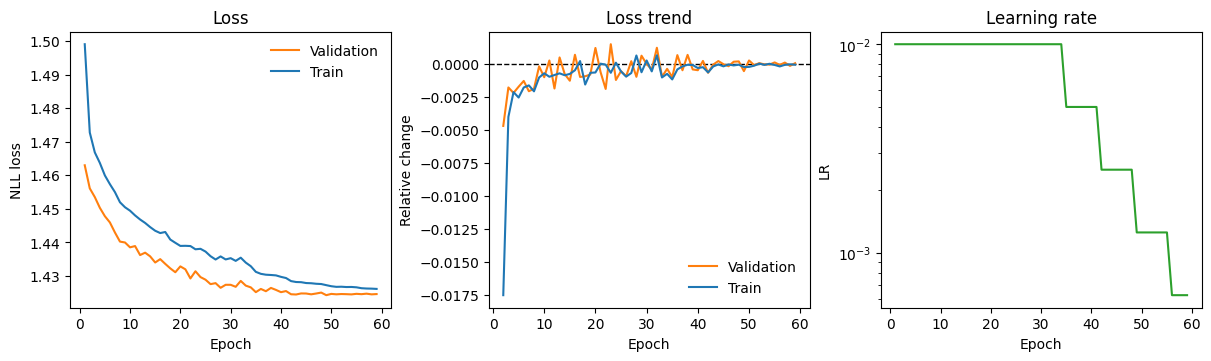

In [12]:
mean_trainer, mean_lit_model = build_lit_model(Conf, loader_generators, "conditional", "identity", True)
mean_trainer.fit(mean_lit_model, train_loader, valid_loader)
plot_training_history(mean_trainer)

Output()

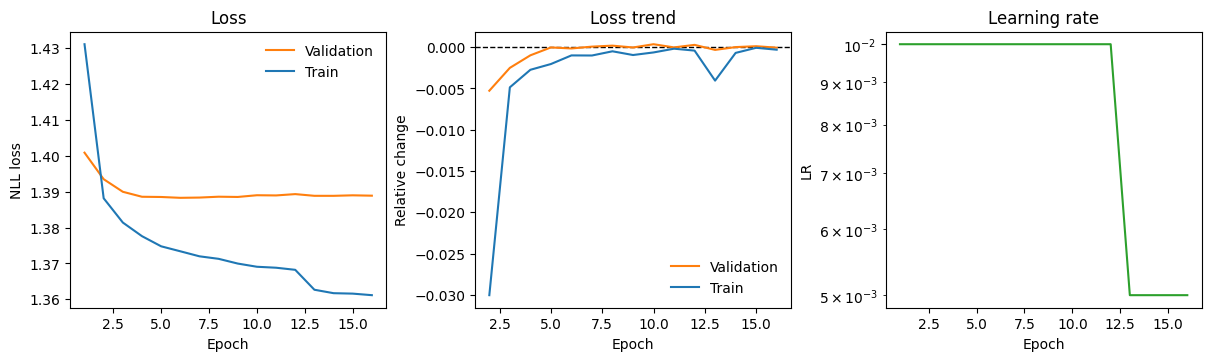

In [22]:
mean_cov_trainer, mean_cov_lit_model = build_lit_model(Conf, loader_generators, "conditional", "shared", True)
mean_lit_model_state_dict = mean_lit_model.full_model.mean_model.state_dict()
mean_cov_lit_model.full_model.mean_model.load_state_dict(mean_lit_model_state_dict, strict=True)
for p in mean_cov_lit_model.full_model.mean_model.parameters():
    p.requires_grad = False
mean_cov_trainer.fit(mean_cov_lit_model, train_loader, valid_loader)
plot_training_history(mean_cov_trainer)

In [15]:
background, explain, shap_values, base_values = compute_shap_values(Conf, mean_lit_model, train_dataset, valid_dataset, n_permutations=100)

In [ ]:
unit_bin_indices = [(5, 20), (13, 5)]
trial_indices = [11, 31]


for unit_idx, bin_idx in unit_bin_indices:
    shap_values_selected = shap_values[:, :, bin_idx, unit_idx]
    base_values_selected = base_values[:, bin_idx, unit_idx]


    data = np.concatenate([explain[0][:, bin_idx], explain[1], (explain[2] > 0).astype(int)], axis=1)


    explanation = shap.Explanation(values=shap_values_selected, base_values=base_values_selected, data=data, feature_names=variable_names)


    file_path = f"./plot/shap/unit-bin/unit-{unit_idx:03d}-bin-{bin_idx:03d}/"

    for trial_idx in trial_indices:
        save_shap_plot(
            lambda: shap.plots.waterfall(explanation[trial_idx], max_display=len(variable_names), show=False),
            title=f"SHAP attribution — Unit {unit_names[unit_idx]}, output bin {bin_times[bin_idx]} s, trial {trial_idx}",
            file_name=f"trial-{trial_idx:03d}",
            file_path=f"{file_path}waterfall/",
        )

    for variable_name in variable_names:
        save_shap_plot(
            lambda: shap.plots.scatter(explanation[:, variable_name], show=False), 
            title=f"SHAP value versus variable-{variable_name} — Unit {unit_names[unit_idx]}, output bin {bin_times[bin_idx]} s", 
            file_name=f"variable-{variable_name}", 
            file_path=f"{file_path}scatter/",
        )

    save_shap_plot(
        lambda: shap.plots.beeswarm(explanation, max_display=len(variable_names), show=False), 
        title=f"Distribution of SHAP attributions across trials — Unit {unit_names[unit_idx]}, output bin {bin_times[bin_idx]} s", 
        file_name=f"beeswarm", 
        file_path=f"{file_path}summary/",
    )

    save_shap_plot(
        lambda: shap.plots.bar(explanation, max_display=len(variable_names), show=False), 
        title=f"Mean absolute SHAP attribution across trials — Unit {unit_names[unit_idx]}, output bin {bin_times[bin_idx]} s", 
        file_name=f"bar", 
        file_path=f"{file_path}summary/",
    )

    save_shap_plot(
        lambda: shap.plots.heatmap(explanation, show=False), 
        title=f"SHAP attributions across trials — Unit {unit_names[unit_idx]}, output bin {bin_times[bin_idx]} s", 
        file_name=f"heatmap", 
        file_path=f"{file_path}summary/",
    )

for trial_idx in trial_indices:
    for variable_idx, variable_name in enumerate(variable_names):        
        plot_shap(
            shap_values=shap_values[trial_idx, variable_idx], 
            title=f"SHAP attribution map — variable-{variable_name}, trial {trial_idx}", 
            file_name=f"variable-{variable_name}", 
            file_path=f"./plot/shap/trial/trial-{trial_idx:03d}/", 
            bin_times=bin_times, 
            unit_names=unit_names,
            cmap="RdBu_r", 
            show=False,
        )

position, dense, sparse = explain

x = np.concatenate((
    position.transpose(0, 2, 1),
    np.broadcast_to(dense[:, :, None], (*dense.shape, Conf.data.n_bins)),
    np.broadcast_to(sparse[:, :, None], (*sparse.shape, Conf.data.n_bins))
), axis=1)

x = x - x.mean(axis=0, keepdims=True)
s = shap_values - shap_values.mean(axis=0, keepdims=True)

shap_pearson = np.einsum("tvb,tvbu->vbu", x, s) / np.sqrt(
    np.sum(x ** 2, axis=0)[..., None] * np.sum(s ** 2, axis=0)
)

for variable_idx, variable_name in enumerate(variable_names):        
    plot_shap(
        shap_values=shap_pearson[variable_idx], 
        title=f"Pearson correlation between input value and SHAP attribution — variable-{variable_name}",
        file_name=f"variable-{variable_name}", 
        file_path=f"./plot/shap/population/pearson-shap-input/", 
        bin_times=bin_times, 
        unit_names=unit_names,
        cmap="RdBu_r", 
        show=False,
    )

for variable_idx, variable_name in enumerate(variable_names):        
    plot_shap(
        shap_values=np.abs(shap_values[:, variable_idx]).mean(axis=0), 
        title=f"Mean absolute SHAP attribution across trials — variable-{variable_name}",
        file_name=f"variable-{variable_name}", 
        file_path=f"./plot/shap/population/mean-absolute-shap/", 
        bin_times=bin_times, 
        unit_names=unit_names,
        cmap="magma", 
        show=False,
    )